# SciPy Bootcamp — W2, Day D3B
```
##### Welch t-test, CUPED, paired t-test on continuous metrics
##### ttest_ind, ttest_rel, CUPED, effect size
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — t-test on real continuous metric
##### Q2 — Impact of outliers on test results
##### Q3 — CUPED in practice
##### Q4 — Paired test — before/after design
##### Q5 — Choose and defend your test


In [20]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — t-test on real continuous metric

```
# Simulate a realistic A/B test on session duration for a health platform:
# Control:   500 users, lognormal(1.3, 0.9) — minutes
# Treatment: 500 users, lognormal(1.45, 0.85) — minutes
# (a) Plot both distributions: histogram + KDE overlay. Are they normal?
# (b) Plot a box plot comparison. Do you see outliers?
# (c) Run Welch's t-test. Compute Cohen's d.
# (d) Plot the null distribution with the observed t-statistic.
# (e) Should you use the mean or median to summarize these groups? Why?
```


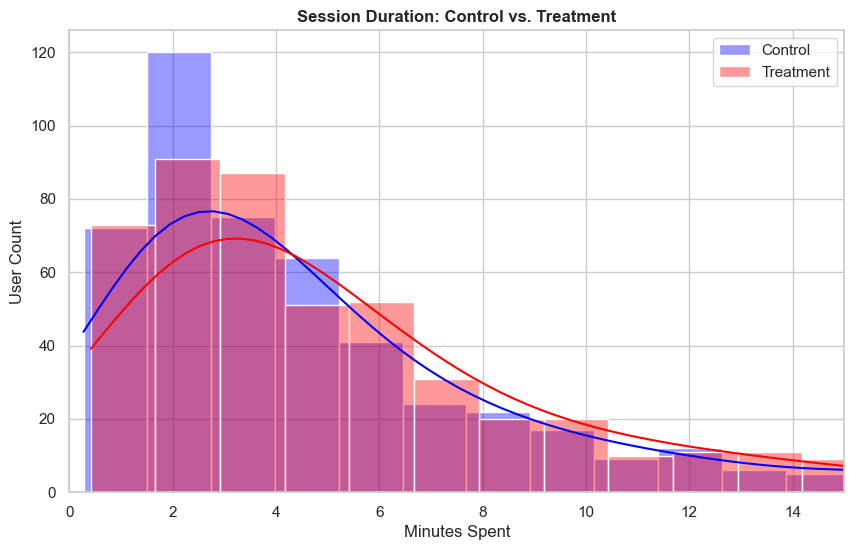

In [21]:
# (a) Plot both distributions: histogram + KDE overlay. Are they normal?

# setup data

np.random.seed(420)
control   = np.random.lognormal(mean=1.3, sigma=0.9, size=500) # minutes
treatment = np.random.lognormal(mean=1.45, sigma=0.85, size=500)

# plotting 
plt.figure(figsize=(10,6))

sns.histplot(control, color='blue', label='Control', kde=True, alpha=0.4)
sns.histplot(treatment, color='red', label='Treatment', kde=True, alpha=0.4)

# Lognormal has a "long tail." Without this, the plot looks very squashed.
plt.xlim(0, 15)

plt.xlabel('Minutes Spent')
plt.ylabel('User Count')
plt.title('Session Duration: Control vs. Treatment', fontweight='bold')
plt.legend()
plt.show()

# The distribution is a textbook example of lognormal which is right-skewed and not bell-shaped

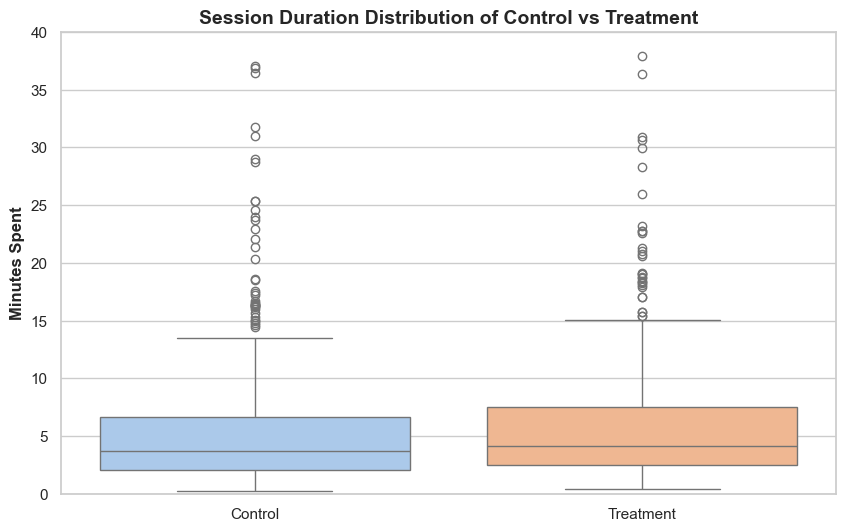

In [22]:
# (b) Plot a box plot comparison. Do you see outliers?
plt.figure(figsize=(10,6))
df = pd.DataFrame({
    'Group' : ['Control']*len(control) + ['Treatment']*len(treatment),
    'Value' : np.concatenate([control, treatment])
})

sns.boxplot(data=df, x='Group', y='Value', hue='Group', palette='pastel')
plt.ylim(0,40)
plt.title('Session Duration Distribution of Control vs Treatment', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Minutes Spent', fontsize=12, fontweight='bold')
plt.show()

In [23]:
# (c) Run Welch's t-test. Compute Cohen's d.
_, p = stats.ttest_ind(control, treatment, equal_var=False)
print(f"p={p:.4f}: Statistically significant (reject H0)" if p < 0.05 else f"p={p:.4f}: Not statistically significant (fail to reject H0)")
pooled_std = np.sqrt((control.std()**2 + treatment.std()**2) / 2)
d = (treatment.mean() - control.mean()) / pooled_std
print(f"Cohen's d={d:.4f}: Large effect" if abs(d) >= 0.8 else f"Cohen's d={d:.4f}: Medium effect" if abs(d) >= 0.5 else f"Cohen's d={d:.4f}: Small effect" if abs(d) >= 0.2 else f"Cohen's d={d:.4f}: Negligible effect")


p=0.0653: Not statistically significant (fail to reject H0)
Cohen's d=0.1168: Negligible effect


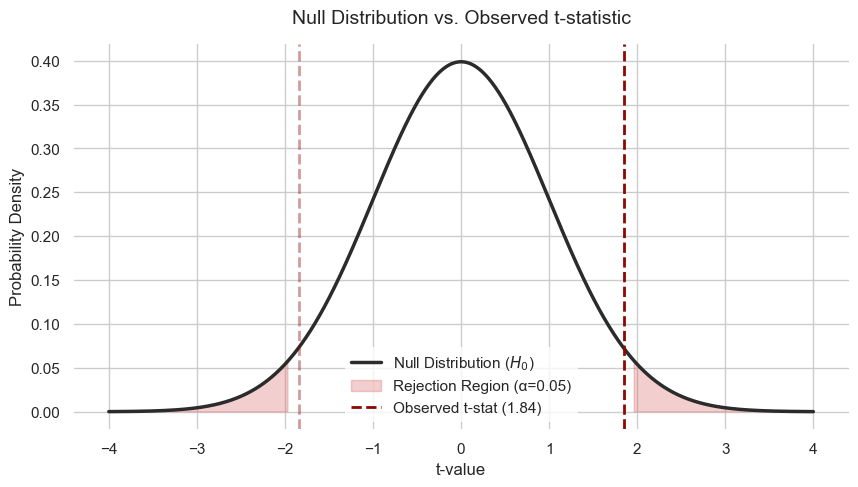

In [24]:
# (d) Plot the null distribution with the observed t-statistic.
n1, n2 = len(control), len(treatment)
v1, v2 = np.var(control, ddof=1), np.var(treatment, ddof=1)
df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2 / (n1-1) + (v2/n2)**2 / (n2-1))
t_stat, p_val = stats.ttest_ind(treatment, control, equal_var=False)

x = np.linspace(-4, 4, 1000)
null_pdf = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))
sns.lineplot(x=x, y=null_pdf, color='#2b2b2b', linewidth=2.5, label='Null Distribution ($H_0$)')

# Shade critical regions (alpha = 0.05, two-tailed)
critical_value = stats.t.ppf(0.975, df)
plt.fill_between(x, null_pdf, where=(x >= critical_value) | (x <= -critical_value), 
                 color=sns.color_palette("muted")[3], alpha=0.3, label='Rejection Region (α=0.05)')

# Overlay the observed t-statistic
plt.axvline(t_stat, color=sns.color_palette("dark")[3], linestyle='--', linewidth=2, 
            label=f'Observed t-stat ({t_stat:.2f})')
plt.axvline(-t_stat, color=sns.color_palette("dark")[3], linestyle='--', linewidth=2, alpha=0.4)

plt.title("Null Distribution vs. Observed t-statistic", fontsize=14, pad=15)
plt.xlabel("t-value", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True) # Clean up borders

plt.show()

````
(e) Should you use the mean or median to summarize these groups? Why?
We should use the median to summarize these groups because session duration follows a highly skewed lognormal distribution, meaning a few extreme power-users would artificially warp the mean. 
The median tracks the exact 50th percentile, providing a more stable and accurate reflection of what a typical user experiences. 
However, if our goal is to calculate total aggregate platform usage for infrastructure or ad metrics, the mean remains necessary.

---

### Q2 — Impact of outliers on test results

```
# Take the control group from Q1. Add 5 extreme outliers (sessions of 120+ minutes).
# (a) Plot before and after adding outliers — histogram and box plot side by side.
# (b) Compare mean vs median before and after. Which is more affected?
# (c) Run t-test before and after adding outliers. How does p-value change?
# (d) Run Mann-Whitney U test before and after. How does IT change?
# (e) Write a comment: what does this tell you about which test to use for revenue/session data?
```


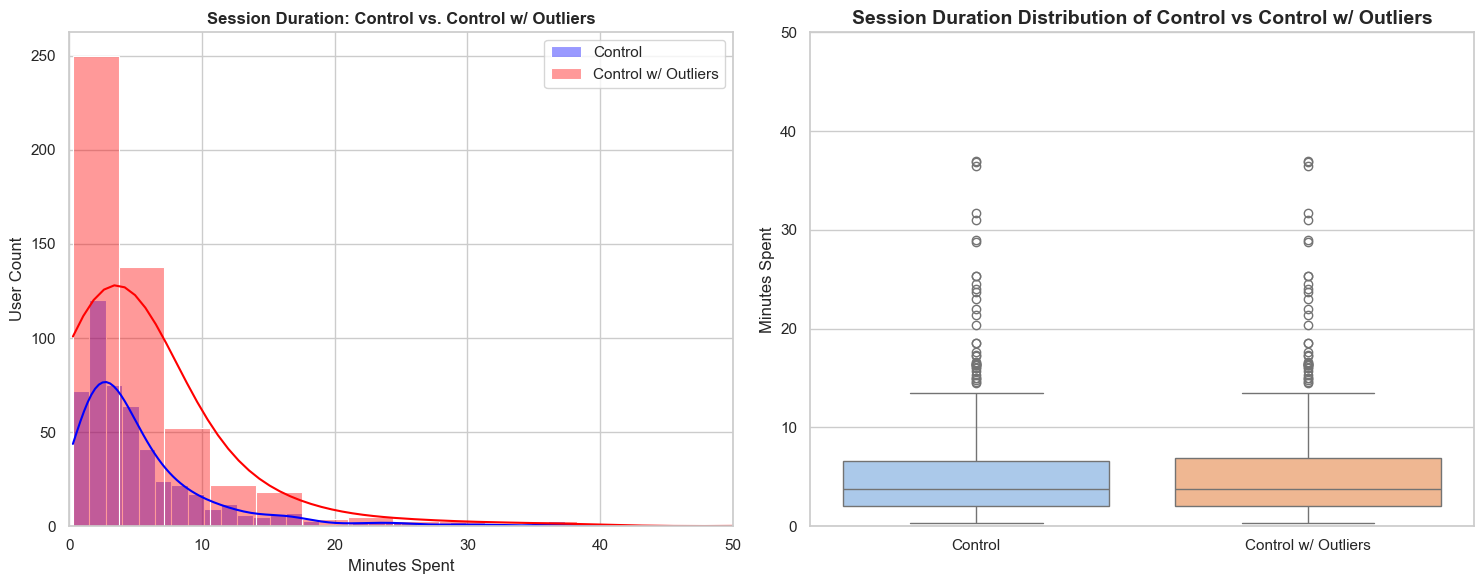

In [25]:
# (a) Plot before and after adding outliers — histogram and box plot side by side.
outliers = np.array([125.0, 142.5, 130.0, 155.5, 122.0])
control_with_outliers = np.concatenate([control, outliers])

# Histogram

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.histplot(control, color='blue', label='Control', kde=True, alpha=0.4)
sns.histplot(control_with_outliers, color='red', label='Control w/ Outliers', kde=True, alpha=0.4)
plt.xlim(0, 50)
plt.xlabel('Minutes Spent')
plt.ylabel('User Count')
plt.title('Session Duration: Control vs. Control w/ Outliers', fontweight='bold')
plt.legend()

# Box plot

df_q2 = pd.DataFrame({
    'Group' : ['Control']*len(control) + ['Control w/ Outliers']*len(control_with_outliers),
    'Value' : np.concatenate([control, control_with_outliers])
})

plt.subplot(1,2,2)
sns.boxplot(data=df_q2, x='Group', y='Value', hue='Group', palette='pastel')
plt.ylim(0,50)
plt.title('Session Duration Distribution of Control vs Control w/ Outliers', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Minutes Spent', fontsize=12)

plt.tight_layout()
plt.show()

In [26]:
# (b) Compare mean vs median before and after. Which is more affected?
print(f'Orginal Control: Mean={np.mean(control):.2f}; Median={np.median(control):.2f}')
print(f'Control w/ Outliers: Mean={np.mean(control_with_outliers):.2f}; Median={np.median(control_with_outliers):.2f}')

# Median is King!

Orginal Control: Mean=5.56; Median=3.73
Control w/ Outliers: Mean=6.84; Median=3.73


In [27]:
# (c) Run t-test before and after adding outliers. How does p-value change?
_, p = stats.ttest_ind(control, treatment, equal_var=False)
print('Origial Control:',f"p={p:.4f}: Statistically significant (reject H0)" if p < 0.05 else f"p={p:.4f}: Not statistically significant (fail to reject H0)")

_, p = stats.ttest_ind(control_with_outliers, treatment, equal_var=False)
print('Control w/ Outliers:',f"p={p:.4f}: Statistically significant (reject H0)" if p < 0.05 else f"p={p:.4f}: Not statistically significant (fail to reject H0)")

# p-value associated with Control with Outliers skyrocketted dramatically! 

Origial Control: p=0.0653: Not statistically significant (fail to reject H0)
Control w/ Outliers: p=0.4415: Not statistically significant (fail to reject H0)


In [28]:
# (d) Run Mann-Whitney U test before and after. How does IT change?
u_orig, p_orig = stats.mannwhitneyu(treatment, control, alternative='two-sided')
u_out, p_out = stats.mannwhitneyu(treatment, control_with_outliers, alternative='two-sided')
print(f"Original Control (MWU): U-stat = {u_orig:.1f}, p-value = {p_orig:.4f}")
print(f"Control w/ Outliers  (MWU): U-stat = {u_out:.1f}, p-value = {p_out:.4f}")

# Unlike the t-test, the Mann-Whitney U test's p-value barely changes at all

Original Control (MWU): U-stat = 136636.0, p-value = 0.0108
Control w/ Outliers  (MWU): U-stat = 136636.0, p-value = 0.0240


```
(e) Write a comment: what does this tell you about which test to use for revenue/session data?
Session and revenue data are highly skewed; a few "whales" (outliers) can artificially inflate variance and cause a t-test to miss real behavioral shifts (producing a false negative).
Use the non-parametric Mann-Whitney U test (or bootstrapping) for robust anomaly-resistant significance testing, but still monitor the mean to track total business/revenue impact.

---

### Q3 — CUPED in practice

```
# Simulate 1000 users. True lift = 0.35 minutes. Pre-experiment correlation with post = 0.65.
# pre_ctrl  = np.random.normal(3.0, 1.5, 500)
# post_ctrl = pre_ctrl * 0.6 + np.random.normal(1.2, 0.9, 500)
# post_trt  = pre_ctrl * 0.6 + np.random.normal(1.55, 0.9, 500) + 0.35
# (a) Plot pre vs post scatter for control group. Show the correlation.
# (b) Apply CUPED adjustment. Plot variance before and after as a bar chart.
# (c) Run t-test on raw and CUPED-adjusted data. Compare p-values.
# (d) What % variance reduction did you achieve?
# (e) If CUPED reduced your required sample size, how many fewer users would you need?
```


In [29]:
np.random.seed(420)
n = 1000

# Simulate the pre-experiment data for all 1000 users
pre_exp = np.random.normal(3.0, 1.5, n)

# Split the pre-experiment data cleanly into two halves of 500
pre_ctrl = pre_exp[:n//2]
pre_trt  = pre_exp[n//2:]

# Simulate post-experiment data using the updated 0.65 correlation scale
control_post   = pre_ctrl * 0.65 + np.random.normal(1.2, 0.9, 500)
# 1.55 already includes the lift!
treatment_post = pre_trt * 0.65 + np.random.normal(1.55, 0.9, 500)

# (c) Run t-test on raw and CUPED-adjusted data. Compare p-values.
# (d) What % variance reduction did you achieve?

# Standard t-test
_, p_standard = stats.ttest_ind(control_post, treatment_post, equal_var=False)

# CUPED: subtract the covariate-correlated component
# We use the Control group to calculate theta because it represents the "clean," 
# natural relationship between past and present behavior, untouched by your experiment.
theta = np.cov(control_post, pre_ctrl)[0,1] / np.var(pre_ctrl)

cuped_control   = control_post   - theta * (pre_exp[:n//2] - pre_exp[:n//2].mean())
cuped_treatment = treatment_post - theta * (pre_exp[n//2:] - pre_exp[n//2:].mean())
_, p_cuped = stats.ttest_ind(cuped_control, cuped_treatment, equal_var=False)


print(f'Standard test p-value: {p_standard:.4f}')
print(f'CUPED test p-value:    {p_cuped:.4f}')
print(f'Variance reduction: {(1 - cuped_control.var()/control_post.var()):.1%}')
print()
print('CUPED detects the same true effect with higher confidence')
print('because it removes user-level noise that was hiding the signal.')


Standard test p-value: 0.0000
CUPED test p-value:    0.0000
Variance reduction: 53.4%

CUPED detects the same true effect with higher confidence
because it removes user-level noise that was hiding the signal.


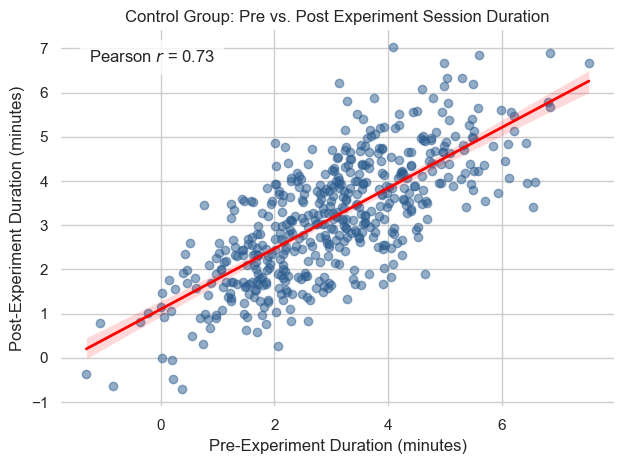

In [30]:
# (a) Plot pre vs post scatter for control group. Show the correlation.

correlation, _ = stats.pearsonr(pre_ctrl, control_post)

# 3. Create a DataFrame for Seaborn
df_ctrl = pd.DataFrame({
    'Pre-Experiment': pre_ctrl,
    'Post-Experiment': control_post
})

# Scatter plot with an automatic linear regression line
ax = sns.regplot(data=df_ctrl, x='Pre-Experiment', y='Post-Experiment', scatter_kws={'alpha': 0.5, 'color': '#2b5c8f'}, line_kws={'color': 'red', 'linewidth': 2})

# Place the correlation value as a text box on the plot
ax.text(x=0.05, y=0.95, s=f"Pearson $r$ = {correlation:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.title("Control Group: Pre vs. Post Experiment Session Duration")
plt.xlabel("Pre-Experiment Duration (minutes)")
plt.ylabel("Post-Experiment Duration (minutes)")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

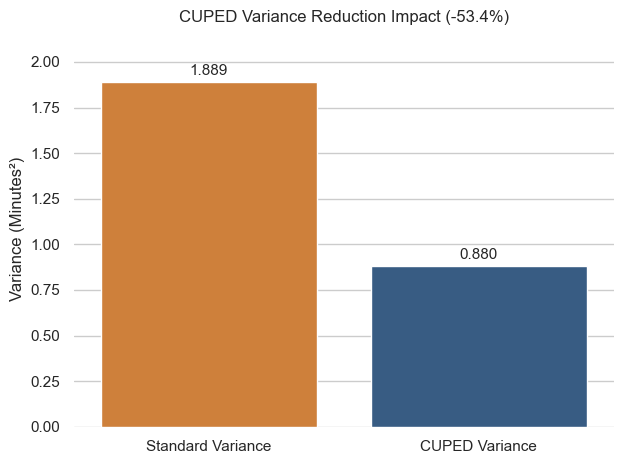

In [31]:
# (b) Apply CUPED adjustment. Plot variance before and after as a bar chart.

# Calculate variances for the Control Group
var_before_cuped = np.var(control_post, ddof=1)
var_after_cuped  = np.var(cuped_control, ddof=1)
pct_reduction = (1 - var_after_cuped / var_before_cuped) * 100

# Create a DataFrame for Seaborn bar plotting
df_variance = pd.DataFrame({
    'Metric': ['Standard Variance', 'CUPED Variance'],
    'Variance Value': [var_before_cuped, var_after_cuped]
})

# 5. Plot the variance reduction
ax = sns.barplot(data=df_variance, x='Metric', y='Variance Value', palette=['#e67e22', '#2b5c8f'], hue='Metric', legend=False)

# Add value labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=11)

# Formatting
plt.title(f"CUPED Variance Reduction Impact (-{pct_reduction:.1f}%)")
plt.xlabel("")
plt.ylabel("Variance (Minutes²)")
plt.ylim(0, max(var_before_cuped, var_after_cuped) * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [32]:
# (e) If CUPED reduced your required sample size, how many fewer users would you need?
var_ratio = cuped_control.var() / control_post.var()
original_n = 1000
required_n_with_cuped = int(np.ceil(original_n * var_ratio))
users_saved = original_n - required_n_with_cuped

print(f"Original required users: {original_n}")
print(f"Required users with CUPED: {required_n_with_cuped}")
print(f"Fewer users needed: {users_saved} users saved")

Original required users: 1000
Required users with CUPED: 466
Fewer users needed: 534 users saved


---

### Q4 — Paired test — before/after design

```
# 150 users complete a task before and after a UX redesign.
# Time to complete (seconds): before ~ Normal(45, 12), after = before * 0.85 + Normal(0, 8)
# (a) Plot scatter: before on x-axis, after on y-axis. Add y=x reference line.
#     Points BELOW the line = improvement. What % improved?
# (b) Plot distribution of (before - after). Add vertical line at 0.
# (c) Run independent AND paired t-test. Compare p-values and explain the difference.
# (d) Compute 95% CI for mean improvement. What does the CI tell you?
```


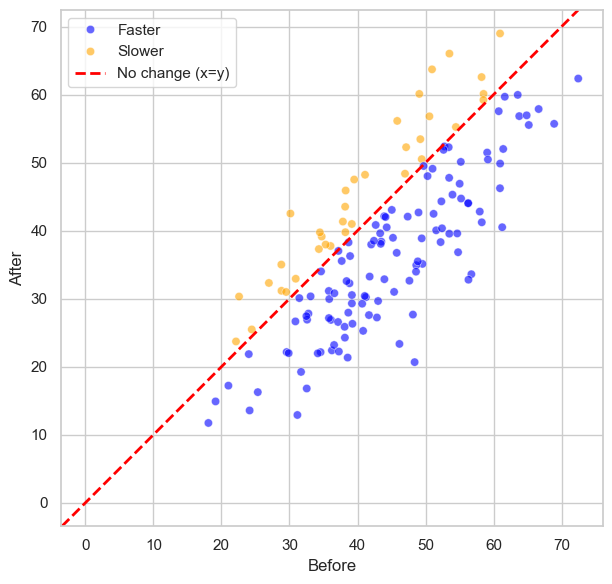

In [33]:
# (a) Plot scatter: before on x-axis, after on y-axis. Add y=x reference line.
#     Points BELOW the line = improvement. What % improved?

np.random.seed(420)
before = np.random.normal(45,12,150) # seconds
after = before * 0.85 + np.random.normal(0,8,150)

improved_mask = after < before
pct_improved = np.mean(after<before)*100

df = pd.DataFrame({
    'Before': before,
    'After': after,
    'Status': np.where(improved_mask, 'Faster', 'Slower')
})


plt.figure(figsize=(10,6))
ax = sns.scatterplot(data=df, x='Before', y='After', hue='Status', palette={'Faster': 'blue', 'Slower': 'orange'}, alpha=.6)

# add the x=y reference line
ax.axline((0,0), (1,1), color='red', linestyle='--', linewidth=2, label='No change (x=y)')

ax.set_aspect('equal', 'box') # Set equal scaling so the square grid isn't distorted

plt.legend()
plt.tight_layout()
plt.show()

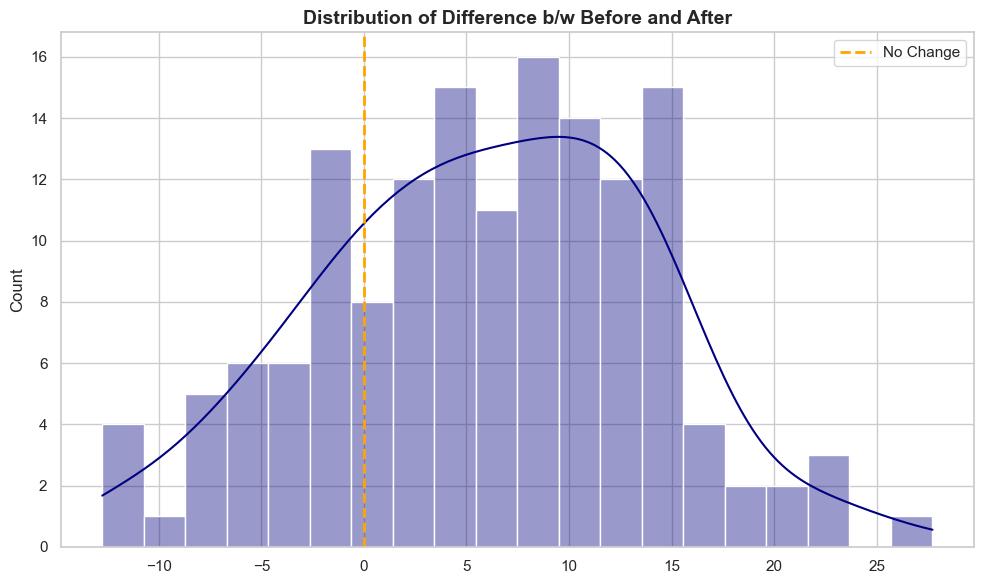

In [34]:
# (b) Plot distribution of (before - after). Add vertical line at 0.

diff = before - after
plt.figure(figsize=(10,6))
sns.histplot(diff, bins=20, kde=True, alpha=0.4, color='navy')

plt.axvline(x=0, color='orange', label='No Change', linestyle='--', linewidth=2)

plt.title('Distribution of Difference b/w Before and After', fontsize=14, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# (c) Run independent AND paired t-test. Compare p-values and explain the difference.
_, p_paired = stats.ttest_rel(before, after)
print(f"Paired t-test p={p_paired:.4f}: Statistically significant (reject H0)" if p_paired < 0.05 else f"Paired t-test p={p_paired:.4f}: Not statistically significant (fail to reject H0)")

# add the indepedent t-test for comparison
_, p_ind = stats.ttest_ind(before, after, equal_var=False)
_, p_paired = stats.ttest_rel(before, after)
print(f"Independent t-test: p={p_ind:.4f}")
print(f"Paired t-test:      p={p_paired:.4f}")
print(f"Paired is {p_ind/p_paired:.1f}x more sensitive")

Paired t-test p=0.0000: Statistically significant (reject H0)
Independent t-test: p=0.0000
Paired t-test:      p=0.0000
Paired is 28178726335.2x more sensitive


In [36]:
# (d) Compute 95% CI for mean improvement. What does the CI tell you?
diff = before - after
lower, upper = stats.t.interval(confidence=0.95, df=len(before)-1, loc=np.mean(diff), scale=stats.sem(diff))
print(f'Mean improvement:     {(before - after).mean():.3f} seconds')
print(f'95% CI for mean improvement: [{lower:.3f}, {upper:.3f}] seconds')

Mean improvement:     5.940 seconds
95% CI for mean improvement: [4.643, 7.237] seconds


```
The 95% confidence interval tells us that if we rolled out the UX redesign to our entire user base, the true population average time savings would fall between 4.6 and 7.2 seconds. 
Because this entire range sits above zero and does not contain 0, it proves that the speed improvement is statistically significant. 
The narrow width of the interval also demonstrates that our estimate is highly precise and reliable due to a sufficient sample size.

---

### Q5 — Choose and defend your test

```
# You receive 4 analysis requests. For each: choose the test, build the chart, run the test,
# and write a 1-sentence conclusion as a markdown cell.
# Request 1: 'Did the new homepage increase revenue per visit?' 
#   revenue ~ lognormal, n=800 per group
# Request 2: 'Did the redesign improve task completion time for existing users?'
#   same 60 users measured before and after, data approximately normal
# Request 3: 'Did the new search ranking increase articles read per session?'
#   articles_read ~ Poisson(3.2) vs Poisson(3.6), n=400 per group
# Request 4: 'Did the new onboarding reduce time-to-first-Subscription?'
#   heavily right-skewed, n=120 per group
# Simulate all datasets yourself. The test choice is the exercise.
```


```
Request 1: Homepage Revenue
Chosen Test: Mann-Whitney U Test (Independent Two-Sample Non-Parametric Test)
Defense: Revenue follows a lognormal distribution which introduces severe right-skewness and extreme outliers. 
Because standard Independent t-tests assume normal distributions, they lose power here. The Mann-Whitney U test evaluates differences in the distributions' medians without requiring normality.

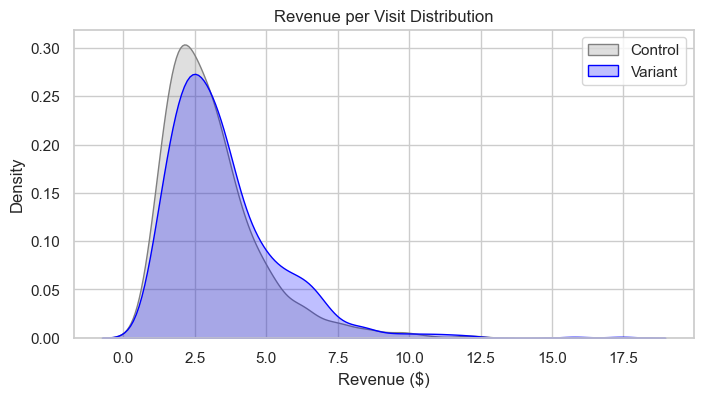

Mann-Whitney U p-value: 0.00002: Statistically significant (reject H0)


In [4]:
np.random.seed(420)

# 1. Simulate Lognormal Revenue (n=800 per group)
control_rev = np.random.lognormal(mean=1.0, sigma=0.5, size=800)
variant_rev = np.random.lognormal(mean=1.1, sigma=0.5, size=800)

# 2. Build the Chart
plt.figure(figsize=(8, 4))
sns.kdeplot(control_rev, label='Control', fill=True, color='gray')
sns.kdeplot(variant_rev, label='Variant', fill=True, color='blue')
plt.title('Revenue per Visit Distribution')
plt.xlabel('Revenue ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3. Run the Statistical Test
u_stat, p_val1 = stats.mannwhitneyu(control_rev, variant_rev, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_val1:.5f}: Statistically significant (reject H0)" if p_val1 < 0.05 else f"Mann-Whitney U p-value: {p_val1:.5f}: Not statistically significant (fail to reject H0)")


```
Request 2: Redesign Task Completion Time
Chosen Test: Paired (Dependent) t-test
Defense: The dataset tracks the exact same group of 60 users across two distinct periods ("before" and "after"). Because the data is approximately normally distributed, a parametric paired t-test is the most powerful tool to measure the mean within-subject difference.

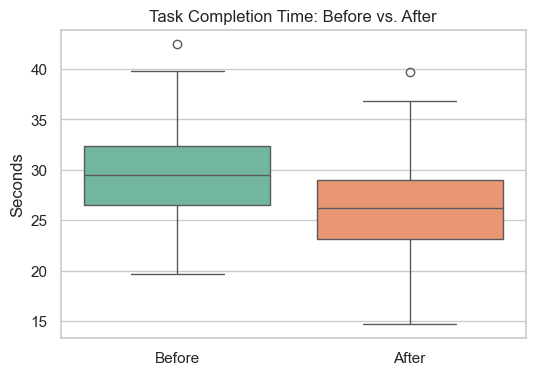

Paired t-test p-value: 0.00000: Statistically significant (reject H0)


In [6]:
# 1. Simulate Normal Paired Data (n=60 users)
base_time = np.random.normal(loc=30, scale=5, size=60)
time_before = base_time + np.random.normal(loc=0, scale=2, size=60)
time_after = base_time - np.random.normal(loc=3, scale=2, size=60) # lower time = improvement

# 2. Build the Chart
plt.figure(figsize=(6, 4))
df_paired = pd.DataFrame({'Before': time_before, 'After': time_after})
sns.boxplot(data=df_paired, palette='Set2')
plt.title('Task Completion Time: Before vs. After')
plt.ylabel('Seconds')
plt.show()

# 3. Run the Statistical Test
t_stat, p_val2 = stats.ttest_rel(time_before, time_after)
print(f"Paired t-test p-value: {p_val2:.5f}: Statistically significant (reject H0)" if p_val2 < 0.05 else f"Paired t-test p-value: {p_val2:.5f}: Not statistically significant (fail to reject H0)")


```
Request 3: Search Ranking Articles Read

Chosen Test: Welch's t-test (Independent Two-Sample t-test with unequal variances)
Defense: Although the underlying data generation process is discrete (Poisson count data), our sample size is large (60 per group). According to the Central Limit Theorem (CLT), the sampling distribution of the sample mean approaches a normal distribution, making a standard two-sample t-test robust and valid.

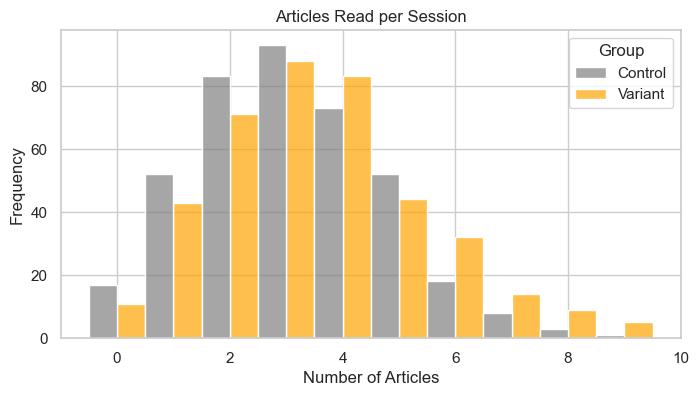

Welch's t-test p-value: 0.00135: Statistically significant (reject H0)


In [14]:
# 1. Simulate Poisson Count Data (n=400 per group)
control_art = np.random.poisson(lam=3.2, size=400)
variant_art = np.random.poisson(lam=3.6, size=400)
df = pd.DataFrame({
    'Articles': np.concatenate([control_art, variant_art]),
    'Group': ['Control']*400 + ['Variant']*400
})

# 2. Build the Chart
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Articles', hue='Group', palette={'Control': 'gray', 'Variant': 'orange'}, alpha=0.7, multiple='dodge', discrete=True)
plt.title('Articles Read per Session')
plt.xlabel('Number of Articles')
plt.ylabel('Frequency')
plt.show()

# 3. Run the Statistical Test
t_stat3, p_val3 = stats.ttest_ind(control_art, variant_art, equal_var=False)
print(f"Welch's t-test p-value: {p_val3:.5f}: Statistically significant (reject H0)" if p_val3 < 0.05 else f"Welch's t-test p-value: {p_val3:.5f}: Not statistically significant (fail to reject H0)")

````
Request 4: Onboarding Time-to-First-Subscription
Chosen Test: Mann-Whitney U Test
Defense: Time-to-first-subscription metrics are notoriously right-skewed (often matching an exponential decay curve) due to a few users taking days while most finish quickly. With a moderate sample size (n=120), outliers heavily skew parametric tests, making the rank-based Mann-Whitney U test a safer choice.

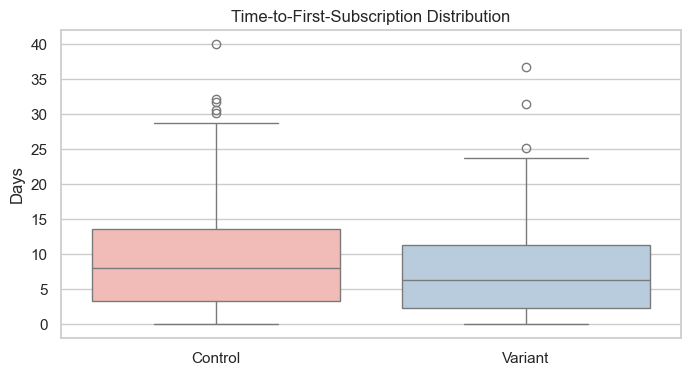

Mann-Whitney U p-value: 0.07903: Not statistically significant (fail to reject H0)


In [ ]:
# 1. Simulate Heavily Right-Skewed Data (n=120 per group)
control_booking = np.random.exponential(scale=10, size=120)
variant_booking = np.random.exponential(scale=7, size=120)

# 2. Build the Chart
plt.figure(figsize=(8, 4))
sns.boxplot(data=[control_booking, variant_booking], palette='Pastel1')
plt.xticks([0, 1], ['Control', 'Variant'])
plt.title('Time-to-First-Subscription Distribution')
plt.ylabel('Days')
plt.show()

# 3. Run the Statistical Test
u_stat4, p_val4 = stats.mannwhitneyu(control_booking, variant_booking, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p_val4:.5f}: Statistically significant (reject H0)" if p_val4 < 0.05 else f"Mann-Whitney U p-value: {p_val4:.5f}: Not statistically significant (fail to reject H0)")